# BM25 Evaluation Results Analysis

This notebook presents the evaluation results of BM25 across different parameter combinations of `k1` and `b`.

It showcases:
- the overall performance for each parameter combination
- the best-performing settings
- per-query performance
- per-category performance
- comparisons using tables and plots

In [2]:
# importing libraries and required files
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')

In [3]:
# Load the evaluation results
df = pd.read_csv("../data/archive-5/bm25_evaluation_results_with_top5_queries.csv", sep=",")
df.head()

,k1,b,MAP,Precision@10_overall,nDCG@10_overall,query,AP,Precision@10_query,nDCG@10_query
0,0.5,0.5,0.5906,0.928,0.9423,film awards best actor,0.778755,1.0,1.000000
1,0.5,0.5,0.5906,0.928,0.9423,minister resignation political party,0.763362,1.0,1.000000
2,0.5,0.5,0.5906,0.928,0.9423,company profits economic growth,0.729798,0.9,0.889954
3,0.5,0.5,0.5906,0.928,0.9423,government election campaign,0.726255,1.0,1.000000
4,0.5,0.5,0.5906,0.928,0.9423,technology company new device,0.717298,1.0,1.000000


In [4]:
# Create a summary DataFrame with the best results for each k1 and b combination
summary_df = (
    df.groupby(["k1", "b"], as_index=False)
      .agg({
          "MAP": "first",
          "Precision@10_overall": "first",
          "nDCG@10_overall": "first"
      })
      .sort_values(
          by=["MAP", "nDCG@10_overall", "Precision@10_overall"],
          ascending=False
      )
      .reset_index(drop=True)
)

summary_df

,k1,b,MAP,Precision@10_overall,nDCG@10_overall
0,1.5,1.00,0.5936,0.936,0.9484
1,1.0,1.00,0.5935,0.932,0.9439
2,2.0,1.00,0.5930,0.936,0.9475
3,1.5,0.75,0.5930,0.932,0.9443
4,2.0,0.75,0.5929,0.936,0.9474
5,1.0,0.75,0.5928,0.932,0.9432
6,0.5,1.00,0.5923,0.920,0.9362
7,1.5,0.50,0.5918,0.932,0.9424
8,2.0,0.50,0.5915,0.932,0.9412
9,0.5,0.75,0.5913,0.916,0.9350


In [27]:
#Best parameter combination based on MAP, nDCG@10, and Precision@10
best_result = summary_df.iloc[0]

print("Best BM25 Parameter Combination:")
print(f"k1 = {best_result['k1']}")
print(f"b = {best_result['b']}")
print(f"MAP = {best_result['MAP']:.4f}")
print(f"Precision@10 = {best_result['Precision@10_overall']:.4f}")
print(f"nDCG@10 = {best_result['nDCG@10_overall']:.4f}")

Best BM25 Parameter Combination:
k1 = 1.5
b = 1.0
MAP = 0.5936
Precision@10 = 0.9360
nDCG@10 = 0.9484


### Best Parameter Combination
We can see that the parameter combination with the best evaluation metric scores is when $k_1$ = 1.5 amd $b$ = 1.0 with an average precision of 0.5936, precision@10 of 0.9360, and nDCG@10 = 0.9484.


In [21]:
#Pivot tables for MAP, Precision@10, and nDCG@10
print("MAP Pivot Table")
display(summary_df.pivot(index="k1", columns="b", values="MAP"))

print("\nPrecision@10 Pivot Table")
display(summary_df.pivot(index="k1", columns="b", values="Precision@10_overall"))

print("\nnDCG@10 Pivot Table")
display(summary_df.pivot(index="k1", columns="b", values="nDCG@10_overall"))

MAP Pivot Table


b,0.25,0.50,0.75,1.00
k1,,,,
0.5,0.5879,0.5906,0.5913,0.5923
1.0,0.5891,0.5912,0.5928,0.5935
1.5,0.5896,0.5918,0.5930,0.5936
2.0,0.5894,0.5915,0.5929,0.5930



Precision@10 Pivot Table


b,0.25,0.50,0.75,1.00
k1,,,,
0.5,0.924,0.928,0.916,0.920
1.0,0.936,0.936,0.932,0.932
1.5,0.928,0.932,0.932,0.936
2.0,0.924,0.932,0.936,0.936



nDCG@10 Pivot Table


b,0.25,0.50,0.75,1.00
k1,,,,
0.5,0.9366,0.9423,0.9350,0.9362
1.0,0.9379,0.9450,0.9432,0.9439
1.5,0.9319,0.9424,0.9443,0.9484
2.0,0.9252,0.9412,0.9474,0.9475


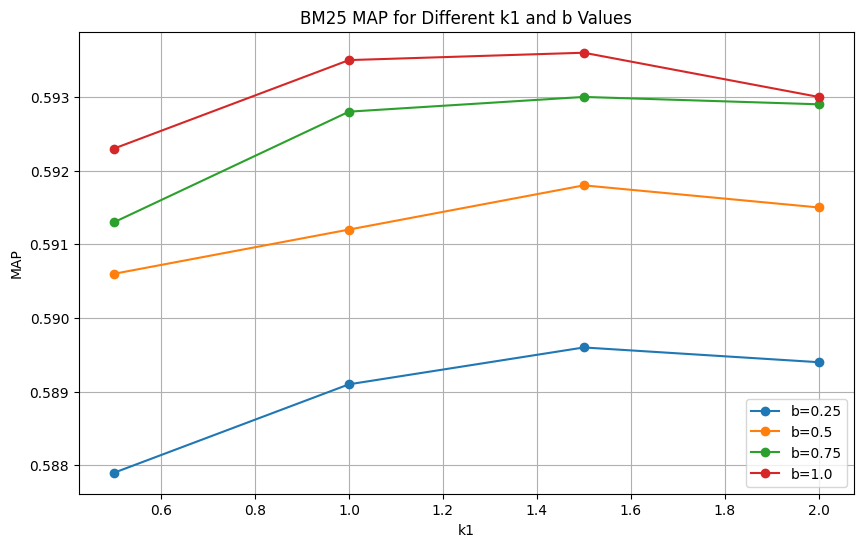

In [22]:
#Visualisation of MAP for different k1 and b values
plt.figure(figsize=(10, 6))
for b_value in sorted(summary_df["b"].unique()):
    subset = summary_df[summary_df["b"] == b_value].sort_values("k1")
    plt.plot(subset["k1"], subset["MAP"], marker="o", label=f"b={b_value}")

plt.xlabel("k1")
plt.ylabel("MAP")
plt.title("BM25 MAP for Different k1 and b Values")
plt.legend()
plt.grid(True)
plt.show()

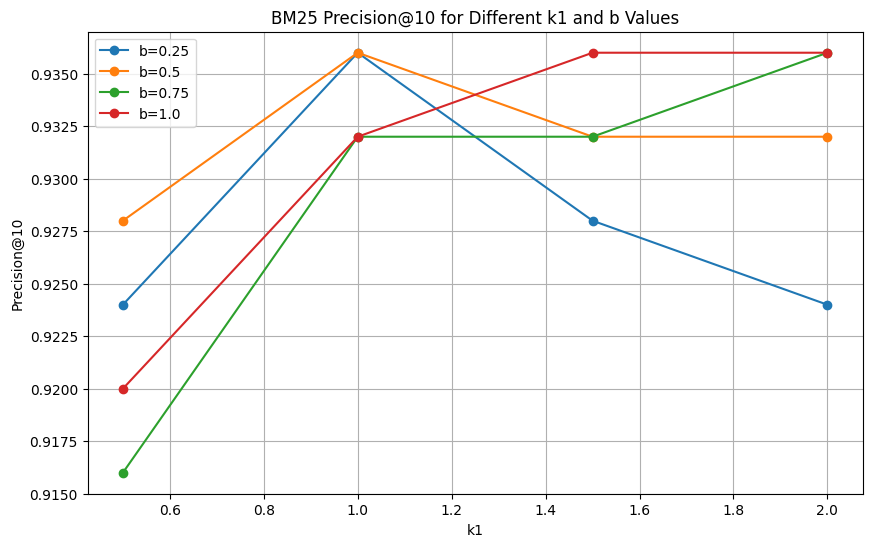

In [23]:
# Visualisation of Precision@10 for different k1 and b values
plt.figure(figsize=(10, 6))
for b_value in sorted(summary_df["b"].unique()):
    subset = summary_df[summary_df["b"] == b_value].sort_values("k1")
    plt.plot(subset["k1"], subset["Precision@10_overall"], marker="o", label=f"b={b_value}")

plt.xlabel("k1")
plt.ylabel("Precision@10")
plt.title("BM25 Precision@10 for Different k1 and b Values")
plt.legend()
plt.grid(True)
plt.show()

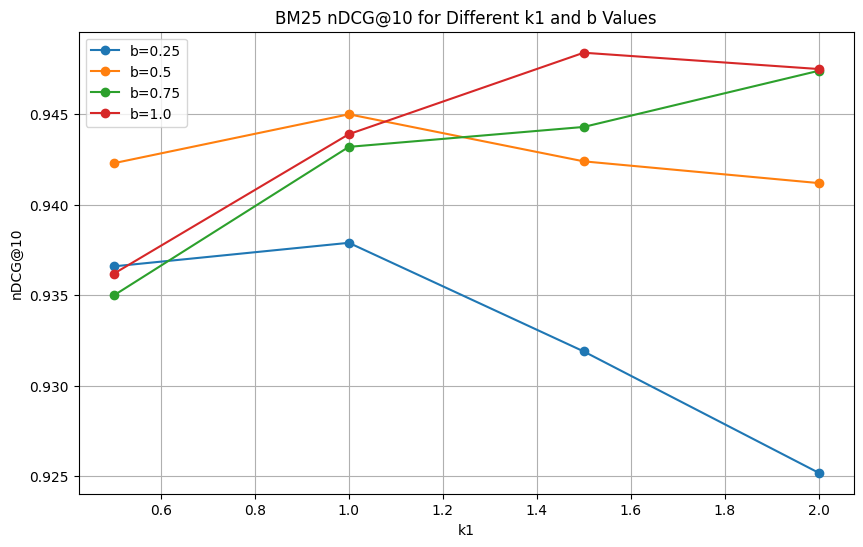

In [24]:
#Visualisation of Precision@10 for different k1 and b values
plt.figure(figsize=(10, 6))
for b_value in sorted(summary_df["b"].unique()):
    subset = summary_df[summary_df["b"] == b_value].sort_values("k1")
    plt.plot(subset["k1"], subset["nDCG@10_overall"], marker="o", label=f"b={b_value}")

plt.xlabel("k1")
plt.ylabel("nDCG@10")
plt.title("BM25 nDCG@10 for Different k1 and b Values")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Merge the evaluation results with the query categories
df_with_category = df.merge(
    query[["query", "category"]].drop_duplicates(),
    on="query",
    how="left"
)

query_performance = (
    df_with_category
    .groupby(["query", "category"], as_index=False)
    .agg(
        mean_AP=("AP", "mean"),
        best_AP=("AP", "max"),
        mean_P10=("Precision@10_query", "mean"),
        mean_nDCG10=("nDCG@10_query", "mean")
    )
    .sort_values(
        by=["mean_AP", "mean_nDCG10", "mean_P10"],
        ascending=False
    )
    .reset_index(drop=True)
)

# Add ranking
query_performance.insert(0, "rank", query_performance.index + 1)

category_performance = (
    df_with_category
    .groupby("category", as_index=False)
    .agg(
        mean_AP=("AP", "mean"),
        mean_P10=("Precision@10_query", "mean"),
        mean_nDCG10=("nDCG@10_query", "mean")
    )
    .sort_values(by="mean_AP", ascending=False)
    .reset_index(drop=True)
)

best_query_per_category = (
    query_performance
    .sort_values(["category", "mean_AP"], ascending=[True, False])
    .groupby("category", as_index=False)
    .first()
)

print("Top Queries (Ranked Across All Parameters)")
display(query_performance.round(4))

print("\nCategory Performance (Which Topics Work Best)")
display(category_performance.round(4))

print("\nBest Query per Category")
display(best_query_per_category[[
    "category", "query", "mean_AP", "mean_P10", "mean_nDCG10"
]].round(4))

Top Queries (Ranked Across All Parameters)


,rank,query,category,mean_AP,best_AP,mean_P10,mean_nDCG10
0,1,film awards best actor,entertainment,0.7754,0.7790,1.0000,1.0000
1,2,minister resignation political party,politics,0.7711,0.7795,1.0000,1.0000
2,3,company profits economic growth,business,0.7410,0.7597,0.9062,0.9022
3,4,government election campaign,politics,0.7270,0.7301,1.0000,1.0000
4,5,football team championship win,sport,0.7155,0.7234,0.9000,0.9069
5,6,technology company new device,tech,0.7135,0.7208,1.0000,1.0000



Category Performance (Which Topics Work Best)


,category,mean_AP,mean_P10,mean_nDCG10
0,entertainment,0.7754,1.0000,1.0000
1,politics,0.7490,1.0000,1.0000
2,business,0.7410,0.9062,0.9022
3,sport,0.7155,0.9000,0.9069
4,tech,0.7135,1.0000,1.0000



Best Query per Category


,category,query,mean_AP,mean_P10,mean_nDCG10
0,business,company profits economic growth,0.7410,0.9062,0.9022
1,entertainment,film awards best actor,0.7754,1.0000,1.0000
2,politics,minister resignation political party,0.7711,1.0000,1.0000
3,sport,football team championship win,0.7155,0.9000,0.9069
4,tech,technology company new device,0.7135,1.0000,1.0000


In [ ]:
# Load the original dataset to analyse category distribution
ogdf = pd.read_csv("../data/archive-5/archive (2)/bbc-news-data.csv",sep="\t")

ogdf['document'] = ogdf['title'] + " " + ogdf ['content']

category_counts = (
    ogdf["category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["category", "doc_count"]

category_counts

,category,doc_count
0,sport,511
1,business,510
2,politics,417
3,tech,401
4,entertainment,386


In [ ]:
# Merge the evaluation results with the query categories
df_with_category = df.merge(
    query[["query", "category"]].drop_duplicates(),
    on="query",
    how="left"
)

category_summary = (
    df_with_category
    .groupby("category", as_index=False)
    .agg(
        mean_AP=("AP", "mean"),
        best_AP=("AP", "max"),
        mean_P10=("Precision@10_query", "mean"),
        best_P10=("Precision@10_query", "max"),
        mean_nDCG10=("nDCG@10_query", "mean"),
        best_nDCG10=("nDCG@10_query", "max"),
        query_count=("query", "nunique")
    )
    .sort_values(
        by=["mean_AP", "mean_nDCG10", "mean_P10"],
        ascending=False
    )
    .reset_index(drop=True)
)
category_summary = category_summary.merge(
    category_counts,
    on="category",
    how="left"
)
print("\nCorrelation Between Dataset Size and Performance")
print(category_summary[["doc_count", "mean_AP"]].corr())

print("\nCategory Summary (Overall Performance by Topic)")
display(category_summary.round(4))

print("\nCategory AP Variance")
display(df_with_category.groupby("category")["AP"].std().round(4))


Correlation Between Dataset Size and Performance
           doc_count   mean_AP
doc_count   1.000000 -0.437984
mean_AP    -0.437984  1.000000

Category Summary (Overall Performance by Topic)


,category,mean_AP,best_AP,mean_P10,best_P10,mean_nDCG10,best_nDCG10,query_count,doc_count
0,entertainment,0.7754,0.7790,1.0000,1.0,1.0000,1.0000,1,386
1,politics,0.7490,0.7795,1.0000,1.0,1.0000,1.0000,2,417
2,business,0.7410,0.7597,0.9062,1.0,0.9022,1.0000,1,510
3,sport,0.7155,0.7234,0.9000,0.9,0.9069,0.9306,1,511
4,tech,0.7135,0.7208,1.0000,1.0,1.0000,1.0000,1,401



Category AP Variance


category
business         0.0106
entertainment    0.0035
politics         0.0229
sport            0.0049
tech             0.0048
Name: AP, dtype: float64